Successfully loaded dataset with 364 tracks.
Identified 42 numeric acoustic features for classification.



--- Baseline (Unweighted) ---
              precision    recall  f1-score   support

   caribbean       0.73      0.93      0.82       245
  westafrica       0.67      0.31      0.43       119

    accuracy                           0.73       364
   macro avg       0.70      0.62      0.62       364
weighted avg       0.71      0.73      0.69       364

Accuracy:          0.7253
Balanced accuracy: 0.6187
Macro F1:          0.6224
Weighted F1:       0.6906
Confusion matrix (rows=true, cols=pred), labels = ['caribbean', 'westafrica']
[[227  18]
 [ 82  37]]

--- Balanced (class_weight='balanced') ---
              precision    recall  f1-score   support

   caribbean       0.73      0.94      0.82       245
  westafrica       0.71      0.29      0.42       119

    accuracy                           0.73       364
   macro avg       0.72      0.62      0.62       364
weighted avg       0.73      0.73      0.69       364

Accuracy:          0.7308
Balanced accuracy: 0.6185
Macro F1:     

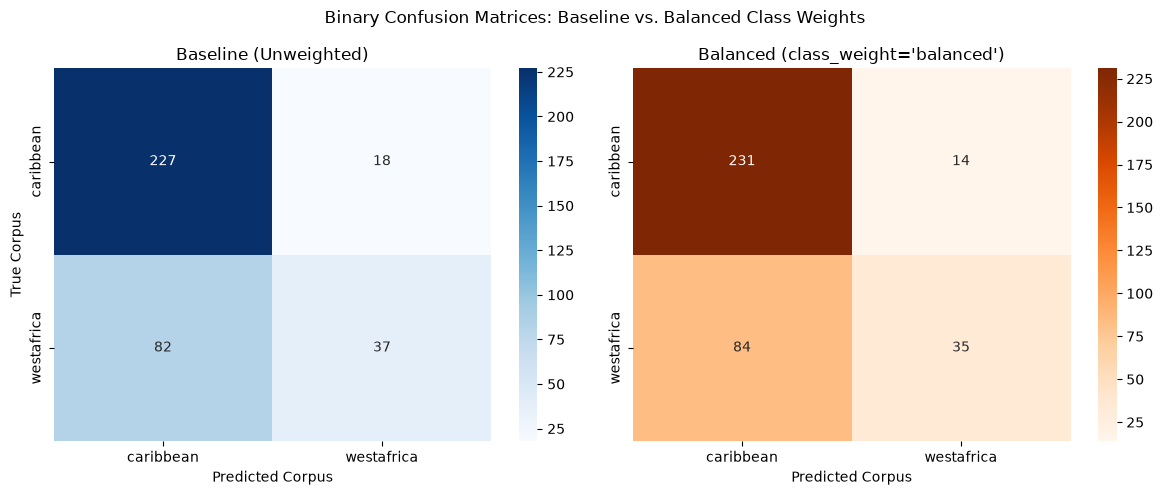

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, balanced_accuracy_score, precision_recall_fscore_support
)
from sklearn.preprocessing import StandardScaler

# Ensure reproducibility across runs
RANDOM_STATE = 42

# ==========================================
# 1. LOAD DATA & DYNAMICALLY EXTRACT FEATURES
#    (unchanged from baseline script)
# ==========================================

OUT_DIR = ("../data/processed")
df = pd.read_csv(f'{OUT_DIR}/features_eda_clean.csv')

metadata_cols = ['track_id', 'genre', 'corpus', 'file_path', 'estimated_key', 'mode']
feature_cols = [col for col in df.columns if col not in metadata_cols and pd.api.types.is_numeric_dtype(df[col])]

print(f"Successfully loaded dataset with {len(df)} tracks.")
print(f"Identified {len(feature_cols)} numeric acoustic features for classification.")

X_raw = df[feature_cols].values
y_binary = df['corpus'].values  # Target: caribbean vs west african

# NOTE: preprocessing is fit on the full X_raw once here, matching the
# baseline script exactly (scaler fit outside the CV loop, as in the
# original code). Because StandardScaler has no access to y and does not
# leak label information, this keeps the balanced-weight comparison
# strictly apples-to-apples with the baseline pipeline you already ran.
# If you later move to a Pipeline(scaler, model) fit per-fold, apply the
# same change to BOTH models so the comparison stays valid.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ==========================================
# 2. BASELINE (UNWEIGHTED) MODEL
# ==========================================
rf_baseline = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
y_pred_baseline = cross_val_predict(rf_baseline, X_scaled, y_binary, cv=cv)

# ==========================================
# 3. BALANCED CLASS-WEIGHT MODEL
#    Only change: class_weight="balanced"
# ==========================================
rf_balanced = RandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1,
    class_weight="balanced"
)
y_pred_balanced = cross_val_predict(rf_balanced, X_scaled, y_binary, cv=cv)

# ==========================================
# 4. SIDE-BY-SIDE METRICS
# ==========================================
classes = np.unique(y_binary)

def summarize(y_true, y_pred, label):
    prec, rec, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=classes, zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred, labels=classes)

    print(f"\n--- {label} ---")
    print(classification_report(y_true, y_pred, zero_division=0))
    print(f"Accuracy:          {acc:.4f}")
    print(f"Balanced accuracy: {bal_acc:.4f}")
    print(f"Macro F1:          {macro_f1:.4f}")
    print(f"Weighted F1:       {weighted_f1:.4f}")
    print("Confusion matrix (rows=true, cols=pred), labels =", list(classes))
    print(cm)

    return {
        'label': label,
        'classes': classes,
        'precision': prec, 'recall': rec, 'f1': f1, 'support': support,
        'accuracy': acc, 'balanced_accuracy': bal_acc,
        'macro_f1': macro_f1, 'weighted_f1': weighted_f1,
        'cm': cm,
    }

res_baseline = summarize(y_binary, y_pred_baseline, "Baseline (Unweighted)")
res_balanced = summarize(y_binary, y_pred_balanced, "Balanced (class_weight='balanced')")

# ==========================================
# 5. PAIRED COMPARISON TABLE
# ==========================================
rows = []
for i, cls in enumerate(classes):
    rows.append({
        'Class': cls,
        'Precision (Baseline)': res_baseline['precision'][i],
        'Precision (Balanced)': res_balanced['precision'][i],
        'Δ Precision': res_balanced['precision'][i] - res_baseline['precision'][i],
        'Recall (Baseline)': res_baseline['recall'][i],
        'Recall (Balanced)': res_balanced['recall'][i],
        'Δ Recall': res_balanced['recall'][i] - res_baseline['recall'][i],
        'F1 (Baseline)': res_baseline['f1'][i],
        'F1 (Balanced)': res_balanced['f1'][i],
        'Δ F1': res_balanced['f1'][i] - res_baseline['f1'][i],
        'Support': res_baseline['support'][i],
    })

df_compare = pd.DataFrame(rows)

overall_row = pd.DataFrame([{
    'Class': 'OVERALL',
    'Precision (Baseline)': np.nan, 'Precision (Balanced)': np.nan, 'Δ Precision': np.nan,
    'Recall (Baseline)': np.nan, 'Recall (Balanced)': np.nan, 'Δ Recall': np.nan,
    'F1 (Baseline)': res_baseline['macro_f1'], 'F1 (Balanced)': res_balanced['macro_f1'],
    'Δ F1': res_balanced['macro_f1'] - res_baseline['macro_f1'],
    'Support': res_baseline['support'].sum(),
}])

df_compare = pd.concat([df_compare, overall_row], ignore_index=True)

print("\n=== Paired Baseline vs. Balanced Comparison ===")
print(df_compare.round(3).to_string(index=False))

summary_stats = pd.DataFrame([
    {'Metric': 'Accuracy', 'Baseline': res_baseline['accuracy'], 'Balanced': res_balanced['accuracy'],
     'Delta': res_balanced['accuracy'] - res_baseline['accuracy']},
    {'Metric': 'Balanced Accuracy', 'Baseline': res_baseline['balanced_accuracy'], 'Balanced': res_balanced['balanced_accuracy'],
     'Delta': res_balanced['balanced_accuracy'] - res_baseline['balanced_accuracy']},
    {'Metric': 'Macro F1', 'Baseline': res_baseline['macro_f1'], 'Balanced': res_balanced['macro_f1'],
     'Delta': res_balanced['macro_f1'] - res_baseline['macro_f1']},
    {'Metric': 'Weighted F1', 'Baseline': res_baseline['weighted_f1'], 'Balanced': res_balanced['weighted_f1'],
     'Delta': res_balanced['weighted_f1'] - res_baseline['weighted_f1']},
])
print("\n=== Overall Metric Deltas ===")
print(summary_stats.round(4).to_string(index=False))

# Save tables for direct inclusion in the thesis (e.g. as a CSV -> paste into Word/LaTeX table)
df_compare.round(3).to_csv(f'{OUT_DIR}/table7b_class_metrics_comparison.csv', index=False)
summary_stats.round(4).to_csv(f'{OUT_DIR}/table7b_overall_metrics_comparison.csv', index=False)

# ==========================================
# 6. SIDE-BY-SIDE CONFUSION MATRICES
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(res_baseline['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title('Baseline (Unweighted)')
axes[0].set_xlabel('Predicted Corpus')
axes[0].set_ylabel('True Corpus')

sns.heatmap(res_balanced['cm'], annot=True, fmt='d', cmap='Oranges',
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title("Balanced (class_weight='balanced')")
axes[1].set_xlabel('Predicted Corpus')
axes[1].set_ylabel('')

plt.suptitle('Binary Confusion Matrices: Baseline vs. Balanced Class Weights')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figure10b_confusion_matrix_comparison.png', dpi=200)
plt.show()

## 1. Imports and Setup


In [2]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


ModuleNotFoundError: No module named 'matplotlib'

## 2. Load Features and Standardize

Same standardization approach as the similarity analysis: z-score every
numeric feature using full-dataset statistics. Clustering and PCA are both
distance-based, so unscaled features (e.g. `tempo_bpm` in the hundreds vs.
`key_correlation` near zero) would otherwise dominate purely due to scale.


In [11]:
FEATURES_PATH = Path("../data/processed/features_eda_clean.csv")


df = pd.read_csv(FEATURES_PATH)
print(f"Loaded {len(df)} rows, {df.shape[1]} columns")

id_cols = [c for c in ["track_id", "file_path", "genre", "corpus", "estimated_key", "mode"] if c in df.columns]
feature_cols = [c for c in df.columns if c not in id_cols]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]

print(f"{len(feature_cols)} numeric feature columns")


Loaded 364 rows, 48 columns
42 numeric feature columns


In [12]:
scaler = StandardScaler()
X = scaler.fit_transform(df[feature_cols])
print("X shape:", X.shape)


X shape: (364, 42)


## 3. Principal Component Analysis (PCA)

We fit PCA on the full standardized feature matrix, then check how much
variance the first 3 components explain against the project's **≥60%**
target. We also plot a scree plot (variance explained per component) to
see how quickly additional components add value beyond the first 3.


Variance explained by first 3 components: 33.4%
Target: >= 60%  |  FAIL


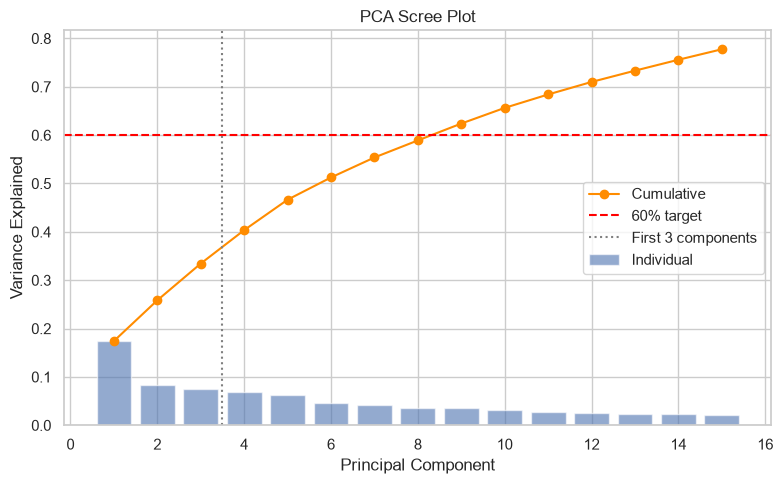

In [13]:
pca_full = PCA(n_components=min(len(feature_cols), len(df)), random_state=RANDOM_STATE)
pca_full.fit(X)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

variance_first_3 = cumulative_var[2] if len(cumulative_var) >= 3 else cumulative_var[-1]
print(f"Variance explained by first 3 components: {variance_first_3:.1%}")
print(f"Target: >= 60%  |  {'PASS' if variance_first_3 >= 0.60 else 'FAIL'}")

plt.figure(figsize=(8, 5))
n_show = min(15, len(explained_var))
plt.bar(range(1, n_show + 1), explained_var[:n_show], alpha=0.6, label="Individual")
plt.plot(range(1, n_show + 1), cumulative_var[:n_show], marker="o", color="darkorange", label="Cumulative")
plt.axhline(0.60, color="red", linestyle="--", label="60% target")
plt.axvline(3.5, color="gray", linestyle=":", label="First 3 components")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("PCA Scree Plot")
plt.legend()
plt.tight_layout()
plt.show()



In [14]:
# 1. Transform the original data into the PCA space
X_pca_all = pca_full.transform(X)

# 2. Slice the matrix to keep only the first 14 principal components
X_pca_14 = X_pca_all[:, :14]

# Confirm the shape is correct (should output: (364, 14))
print(f"PCA matrix shape: {X_pca_14.shape}")


PCA matrix shape: (364, 14)


## 4. 2D PCA Visualization

For visualization (not for the clustering itself, which uses the full
standardized feature space), we project down to the first 2 components and
color points by genre and by corpus, to get a first visual sense of
whether genres separate at all in acoustic space before running any
clustering algorithm.


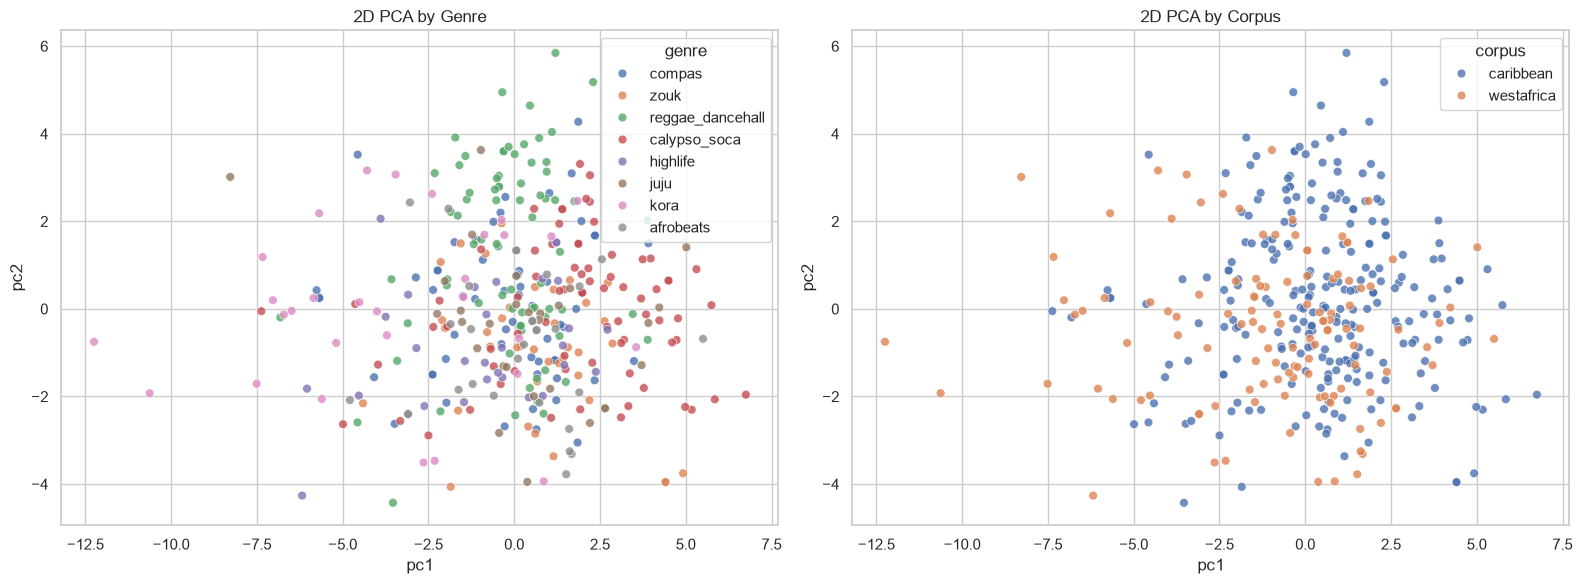

In [5]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X)

plot_df = df[["track_id", "genre", "corpus"]].copy()
plot_df["pc1"] = X_2d[:, 0]
plot_df["pc2"] = X_2d[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=plot_df, x="pc1", y="pc2", hue="genre", ax=axes[0], s=40, alpha=0.8)
axes[0].set_title("2D PCA by Genre")

sns.scatterplot(data=plot_df, x="pc1", y="pc2", hue="corpus", ax=axes[1], s=40, alpha=0.8)
axes[1].set_title("2D PCA by Corpus")

plt.tight_layout()
plt.show()


## 5. K-Means: Choosing *k* (Elbow Method + Silhouette Score)

We don't assume *k* should equal 8 (the number of genre labels) — the
whole point of this analysis is to see whether the **natural** number of
acoustic groupings matches genre labels or not. We scan a range of *k*
values and look at both the elbow in within-cluster sum of squares
(inertia) and the silhouette score, which more directly measures cluster
separation quality and maps onto this project's evaluation target.


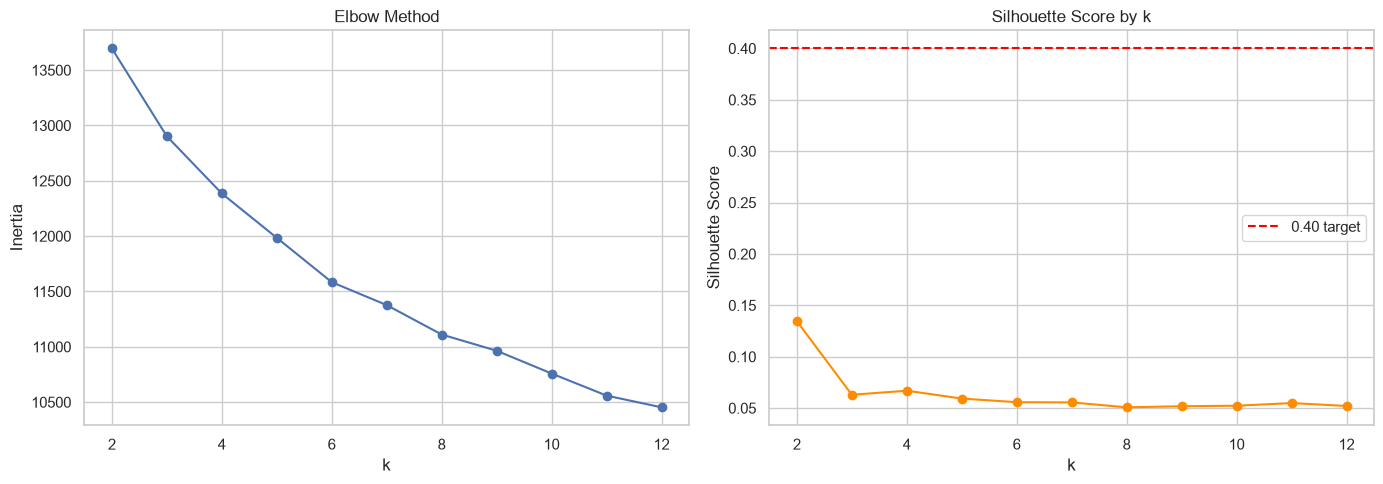

k with highest silhouette score: 2 (score = 0.135)


In [6]:
k_range = range(2, 13)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(list(k_range), silhouette_scores, marker="o", color="darkorange")
axes[1].axhline(0.40, color="red", linestyle="--", label="0.40 target")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")
axes[1].legend()

plt.tight_layout()
plt.show()

best_k_by_silhouette = list(k_range)[int(np.argmax(silhouette_scores))]
print(f"k with highest silhouette score: {best_k_by_silhouette} (score = {max(silhouette_scores):.3f})")


## 6. Fit Final K-Means Model

We fit K-Means at **k = 8** to directly compare against genre labels (the
project's central question), and separately note the silhouette-optimal
*k* found above for reference — these may not be the same value, and that
gap is itself informative: if the silhouette-optimal *k* is far from 8,
it suggests the natural acoustic structure doesn't cleanly match the
genre taxonomy.


In [7]:
K_FOR_GENRE_COMPARISON = 8

kmeans_final = KMeans(n_clusters=K_FOR_GENRE_COMPARISON, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X)

kmeans_silhouette = silhouette_score(X, kmeans_labels)
print(f"K-Means (k={K_FOR_GENRE_COMPARISON}) silhouette score: {kmeans_silhouette:.3f}")
print(f"Target: >= 0.40  |  {'PASS' if kmeans_silhouette >= 0.40 else 'FAIL'}")

df["kmeans_cluster"] = kmeans_labels


K-Means (k=8) silhouette score: 0.051
Target: >= 0.40  |  FAIL


## 7. Hierarchical Agglomerative Clustering (HAC)

We compute a linkage matrix using Ward's method (minimizes within-cluster
variance, the standard choice for HAC when later cutting into a fixed
number of clusters) and visualize it as a dendrogram. We then cut the tree
at the same *k = 8* used for K-Means, so the two methods' cluster
assignments are directly comparable against each other and against genre.


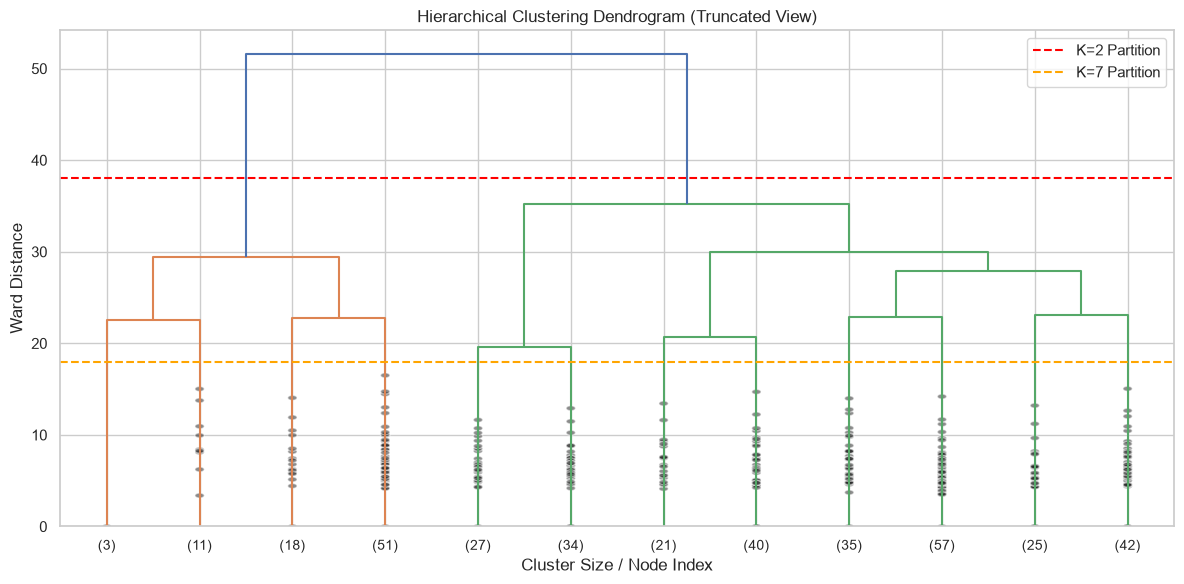

In [15]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage



linkage_matrix = linkage(X, method="ward")

plt.figure(figsize=(12, 6))

# Truncate to show only the last 12 merged clusters
dendrogram(
    linkage_matrix,
    truncate_mode="lastp",  # Show only the last p merged clusters
    p=12,  # Number of clusters to display at the bottom
    show_contracted=True,  # Draws small dots to show collapsed tracks
    leaf_rotation=0,  # Labels look cleaner horizontal when text is short
    leaf_font_size=10,
)

# Add your thesis reference lines for K=2 and K=7
# You can adjust the 'y' values based on your Ward Distance axis
plt.axhline(y=38, color="red", linestyle="--", label="K=2 Partition")
plt.axhline(y=18, color="orange", linestyle="--", label="K=7 Partition")

plt.title("Hierarchical Clustering Dendrogram (Truncated View)")
plt.xlabel("Cluster Size / Node Index")
plt.ylabel("Ward Distance")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()



LEAF INDEX ANALYSIS FOR MANUSCRIPT QUALIFIERS
Visual Leaf #1 Label (19) -> Total Tracks: 19
   - 3 tracks of compas
   - 5 tracks of reggae_dancehall
   - 3 tracks of calypso_soca
   - 1 tracks of zouk
   - 1 tracks of kora
   - 3 tracks of highlife
   - 3 tracks of afrobeats
Visual Leaf #2 Label (3) -> Total Tracks: 3
   - 3 tracks of compas
Visual Leaf #3 Label (22) -> Total Tracks: 22
   - 14 tracks of kora
   - 2 tracks of calypso_soca
   - 1 tracks of juju
   - 2 tracks of highlife
   - 2 tracks of compas
   - 1 tracks of reggae_dancehall
Visual Leaf #4 Label (35) -> Total Tracks: 35
   - 26 tracks of reggae_dancehall
   - 3 tracks of compas
   - 2 tracks of afrobeats
   - 3 tracks of kora
   - 1 tracks of zouk
Visual Leaf #5 Label (21) -> Total Tracks: 21
   - 5 tracks of reggae_dancehall
   - 3 tracks of highlife
   - 1 tracks of juju
   - 1 tracks of kora
   - 2 tracks of zouk
   - 5 tracks of calypso_soca
   - 3 tracks of compas
   - 1 tracks of afrobeats
Visual Leaf #6 Label 

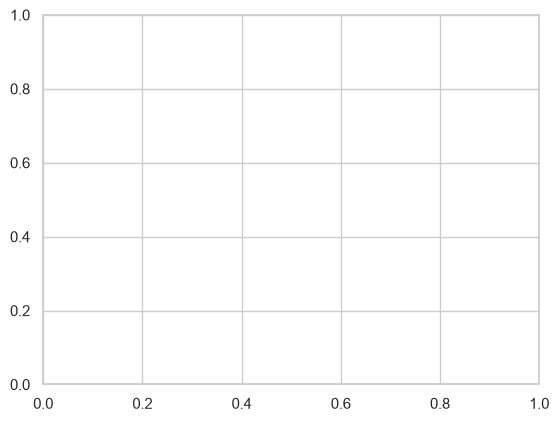

In [27]:
from collections import Counter
import numpy as np
from scipy.cluster.hierarchy import to_tree

# 1. Reconstruct the full tree topology from your linkage matrix
root_node, node_list = to_tree(linkage_matrix, rd=True)

# 2. Replicate the exact 'lastp' truncation logic used by your plot (p=12)
# This extracts the absolute track indices assigned to each of the 12 visible leaves
# (Note: dendrogram numbers leaf labels from left-to-right as they appear visually)
icoord = plt.gca().get_images() # or just read from dendrogram dict directly
dend_dict = dendrogram(linkage_matrix, truncate_mode="lastp", p=12, no_plot=True)
leaves = dend_dict['leaves']

print("LEAF INDEX ANALYSIS FOR MANUSCRIPT QUALIFIERS")
print("=" * 65)

# 3. Print the exact composition of each leaf node
for i, leaf_id in enumerate(leaves):
    # Retrieve the true track row indices belonging to this leaf/cluster
    if leaf_id < len(X):
        track_indices = [leaf_id]
    else:
        track_indices = node_list[leaf_id].pre_order(lambda x: x.id)
        
    # Match indices back to your original DataFrame metadata
    # (Adjust 'df' and 'genre' column name if they differ in your script)
    genres_in_leaf = df.iloc[track_indices]['genre'].tolist()
    counts = Counter(genres_in_leaf)
    
    # Format the printout to match your visual label
    visual_label = f"({len(track_indices)})" if leaf_id >= len(X) else f" {leaf_id} "
    print(f"Visual Leaf #{i+1} Label {visual_label} -> Total Tracks: {len(track_indices)}")
    for genre, count in counts.items():
        print(f"   - {count} tracks of {genre}")


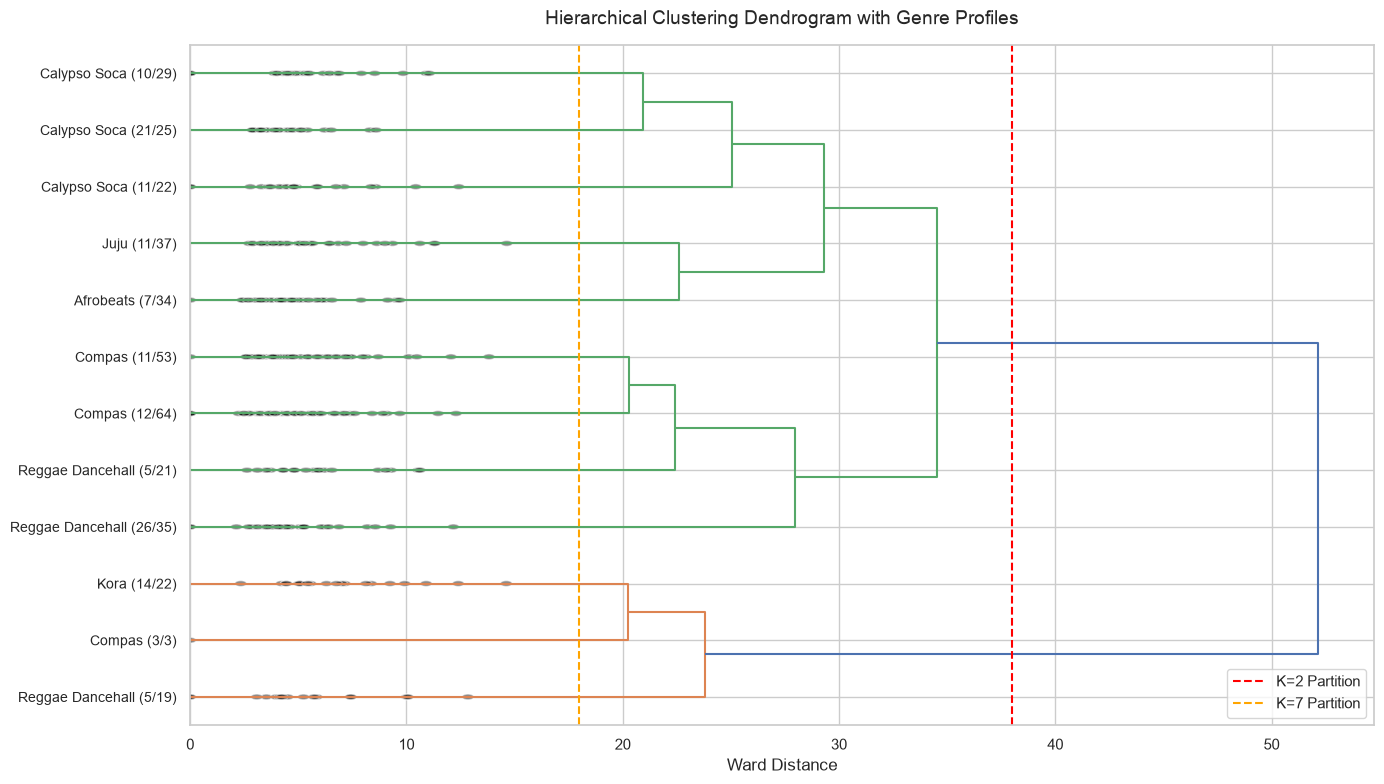

In [19]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, to_tree

# 1. Compute your linkage matrix
linkage_matrix = linkage(X_pca_14, method="ward")

# 2. Get the root tree object to map nodes back to original elements
root_node, node_list = to_tree(linkage_matrix, rd=True)


# 3. Create the custom label function
def make_custom_labels(id):
    if id < len(df):
        return str(df["genre"].iloc[id])

    node = node_list[id]
    track_indices = node.pre_order()
    genre_counts = df["genre"].iloc[track_indices].value_counts()

    top_genre = genre_counts.index[0]
    top_count = genre_counts.values[0]
    total_in_node = len(track_indices)

    # Clean up names for a cleaner layout
    clean_name = str(top_genre).replace("_", " ").title()
    return f"{clean_name} ({top_count}/{total_in_node})"


# 4. Generate a horizontal layout plot
plt.figure(figsize=(14, 8))

dendrogram(
    linkage_matrix,
    orientation="right",  # Rotates the entire tree sideways
    truncate_mode="lastp",
    p=12,
    leaf_label_func=make_custom_labels,
    leaf_font_size=10,  # Perfectly readable at 0 degrees horizontal
    show_contracted=True,
)

# Reference lines for K=2 and K=7 partitions (using axvline since the scale is now on the X-axis)
plt.axvline(x=38, color="red", linestyle="--", label="K=2 Partition")
plt.axvline(x=18, color="orange", linestyle="--", label="K=7 Partition")

plt.title(
    "Hierarchical Clustering Dendrogram with Genre Profiles",
    fontsize=14,
    pad=15,
)
plt.xlabel("Ward Distance", fontsize=12)
plt.legend(loc="lower right", fontsize=11)

# Add clear spacing on the right margin for the horizontal labels
plt.subplots_adjust(right=0.75)
plt.tight_layout()
plt.show()


In [9]:
hac_final = AgglomerativeClustering(n_clusters=K_FOR_GENRE_COMPARISON, linkage="ward")
hac_labels = hac_final.fit_predict(X)

hac_silhouette = silhouette_score(X, hac_labels)
print(f"HAC (k={K_FOR_GENRE_COMPARISON}) silhouette score: {hac_silhouette:.3f}")
print(f"Target: >= 0.40  |  {'PASS' if hac_silhouette >= 0.40 else 'FAIL'}")

df["hac_cluster"] = hac_labels


HAC (k=8) silhouette score: 0.032
Target: >= 0.40  |  FAIL


## 8. Cross-Tabulate Cluster Membership Against Genre and Corpus

This is the key interpretive step: for each clustering method, we
cross-tabulate which genres/corpora ended up in which cluster. A clean
diagonal-ish pattern would mean clusters closely track genre; a scattered
pattern means tracks group acoustically across genre boundaries — which is
itself an interesting finding, since it would suggest some genres share
more acoustic common ground with each other (potentially across corpora)
than their genre label alone implies.


In [10]:
print("K-Means clusters vs genre:")
kmeans_crosstab = pd.crosstab(df["genre"], df["kmeans_cluster"])
display(kmeans_crosstab)

print("\nK-Means clusters vs corpus:")
display(pd.crosstab(df["corpus"], df["kmeans_cluster"]))


K-Means clusters vs genre:


kmeans_cluster,0,1,2,3,4,5,6,7
genre,,,,,,,,
afrobeats,6,2,2,0,11,1,5,3
calypso_soca,10,3,4,3,9,24,6,16
compas,9,10,14,5,9,3,2,5
highlife,5,1,4,5,9,3,3,0
juju,6,3,12,2,3,3,0,0
kora,4,5,0,14,4,0,1,2
reggae_dancehall,4,37,6,1,12,4,9,2
zouk,13,2,4,0,8,6,2,3



K-Means clusters vs corpus:


kmeans_cluster,0,1,2,3,4,5,6,7
corpus,,,,,,,,
caribbean,36,52,28,9,38,37,19,26
westafrica,21,11,18,21,27,7,9,5


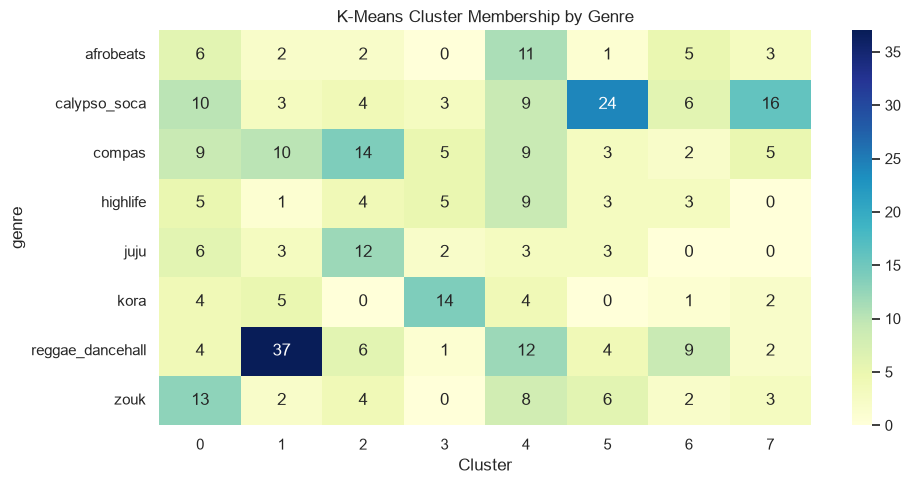

In [11]:
plt.figure(figsize=(10, 5))
sns.heatmap(kmeans_crosstab, annot=True, fmt="d", cmap="YlGnBu")
plt.title("K-Means Cluster Membership by Genre")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()


In [12]:
print("HAC clusters vs genre:")
hac_crosstab = pd.crosstab(df["genre"], df["hac_cluster"])
display(hac_crosstab)

print("\nHAC clusters vs corpus:")
display(pd.crosstab(df["corpus"], df["hac_cluster"]))


HAC clusters vs genre:


hac_cluster,0,1,2,3,4,5,6,7
genre,,,,,,,,
afrobeats,9,0,2,8,9,1,0,1
calypso_soca,10,2,4,8,9,20,17,5
compas,8,3,9,12,11,3,3,8
highlife,14,0,1,5,4,4,0,2
juju,6,1,3,2,7,3,0,7
kora,9,8,5,3,3,0,1,1
reggae_dancehall,8,0,36,17,1,6,1,6
zouk,5,0,1,6,13,5,3,5



HAC clusters vs corpus:


hac_cluster,0,1,2,3,4,5,6,7
corpus,,,,,,,,
caribbean,31,5,50,43,34,34,24,24
westafrica,38,9,11,18,23,8,1,11


## 9. Per-Cluster Silhouette Detail

Beyond the single average silhouette score, we look at the distribution of
per-sample silhouette values for the K-Means solution, to check whether
poor average performance (if any) comes from a few weak clusters or is
spread evenly — this matters for deciding whether the result is "mostly
good with one bad cluster" versus "uniformly mediocre."


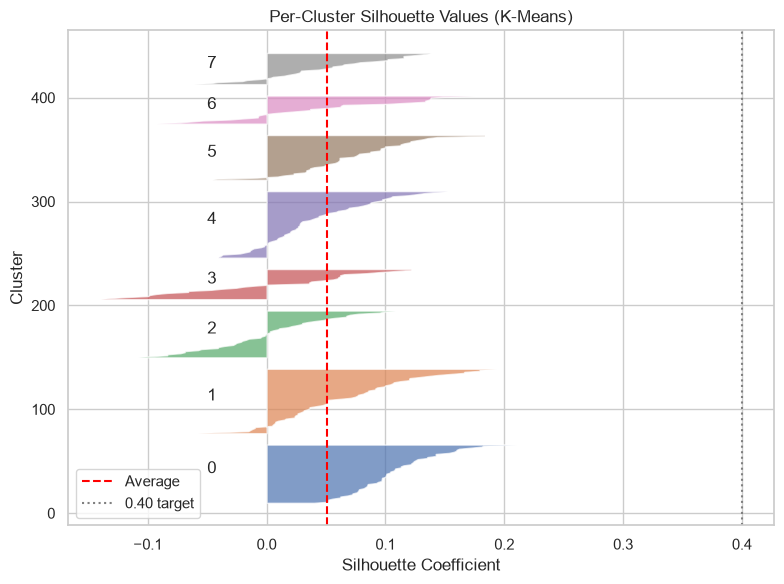

In [13]:
sample_silhouette_values = silhouette_samples(X, kmeans_labels)

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
for i in range(K_FOR_GENRE_COMPARISON):
    cluster_silhouette_vals = sample_silhouette_values[kmeans_labels == i]
    cluster_silhouette_vals.sort()
    size = len(cluster_silhouette_vals)
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(i))
    y_lower = y_upper + 10

ax.axvline(kmeans_silhouette, color="red", linestyle="--", label="Average")
ax.axvline(0.40, color="gray", linestyle=":", label="0.40 target")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.set_title("Per-Cluster Silhouette Values (K-Means)")
ax.legend()
plt.tight_layout()
plt.show()


## 10. Evaluation Summary and Save Results

We compile the project's three clustering/PCA-related targets into a
single pass/fail summary, and save both the track-level cluster
assignments and this evaluation summary to disk.


In [14]:
evaluation_summary = {
    "pca_variance_first_3_components": float(variance_first_3),
    "pca_variance_target": 0.60,
    "pca_variance_pass": bool(variance_first_3 >= 0.60),
    "kmeans_k": K_FOR_GENRE_COMPARISON,
    "kmeans_silhouette_score": float(kmeans_silhouette),
    "hac_silhouette_score": float(hac_silhouette),
    "silhouette_target": 0.40,
    "kmeans_silhouette_pass": bool(kmeans_silhouette >= 0.40),
    "hac_silhouette_pass": bool(hac_silhouette >= 0.40),
    "silhouette_optimal_k": int(best_k_by_silhouette),
    "silhouette_optimal_k_score": float(max(silhouette_scores)),
}

print(json.dumps(evaluation_summary, indent=2))

OUT_DIR = Path("../data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

assignments_path = OUT_DIR / "cluster_assignments.csv"
df[["track_id", "genre", "corpus", "kmeans_cluster", "hac_cluster"]].to_csv(assignments_path, index=False)
print(f"Saved cluster assignments to {assignments_path}")

summary_path = OUT_DIR / "cluster_evaluation_summary.json"
with open(summary_path, "w") as f:
    json.dump(evaluation_summary, f, indent=2)
print(f"Saved evaluation summary to {summary_path}")


{
  "pca_variance_first_3_components": 0.33439214456715083,
  "pca_variance_target": 0.6,
  "pca_variance_pass": false,
  "kmeans_k": 8,
  "kmeans_silhouette_score": 0.050729746985081065,
  "hac_silhouette_score": 0.03172110943717935,
  "silhouette_target": 0.4,
  "kmeans_silhouette_pass": false,
  "hac_silhouette_pass": false,
  "silhouette_optimal_k": 2,
  "silhouette_optimal_k_score": 0.1345635156787658
}
Saved cluster assignments to ../data/processed/cluster_assignments.csv
Saved evaluation summary to ../data/processed/cluster_evaluation_summary.json
